# Voronoi tessellations: uniform vs. non-uniform point patterns

**Reference:** Kashyap, Kiran & Gupta, *Emergence of Local Ordering and Mesoscale Giant
Number Fluctuations in Active Turbulence* (arXiv:2507.04890v2) — Section **S4: Voronoi analysis
of vortex-center distribution**.

In the paper, the positions of intense **vortex centers** are analysed with a Voronoi
tessellation. The *area of each Voronoi cell* is a local proxy for the inverse density of
centers: small cells sit inside dense clusters, large cells span voids. For a **spatially
homogeneous** (uniform-random) arrangement the distribution of cell areas is *narrow and
peaked*; as activity increases the centers **cluster**, voids open up, and the area
distribution **broadens** and departs from the homogeneous reference (Fig. S6).

This notebook reproduces that idea on synthetic point clouds:

1. generate two point patterns — one **uniform** (Poisson / homogeneous), one **non-uniform**
   (clustered with voids);
2. build the **Voronoi tessellation** of each;
3. compute the **PDF of cell area** (area vs. probability of that area) for both;
4. **compare** the two PDFs.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d

rng = np.random.default_rng(7)        # reproducible
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

# ---- domain ----
L = 1.0                                # unit square [0, L] x [0, L]
N = 1200                               # number of "vortex centers" in each pattern


## 1. Two point patterns

**Uniform (homogeneous):** `N` points drawn independently and uniformly over the box — a
Poisson point process, the reference for a structureless / low-activity field.

**Non-uniform (clustered):** the same number of points, but most of them are packed into a
handful of compact Gaussian **clusters** while a thin uniform background fills the rest. This
produces the dense-region/void morphology the paper associates with **high activity**
($\alpha < \alpha_c$).


In [2]:
def uniform_points(n, L, rng):
    return rng.uniform(0, L, size=(n, 2))

def clustered_points(n, L, rng, n_clusters=5, bg_frac=0.45, spread=0.06):
    '''Most points in tight Gaussian blobs + a sparse uniform background.'''
    n_bg = int(bg_frac * n)
    n_cl = n - n_bg
    centers = rng.uniform(0.12 * L, 0.88 * L, size=(n_clusters, 2))
    # uneven cluster populations -> stronger inhomogeneity
    weights = rng.uniform(0.4, 1.0, size=n_clusters); weights /= weights.sum()
    counts = rng.multinomial(n_cl, weights)
    pts = [rng.normal(centers[k], spread * L, size=(c, 2)) for k, c in enumerate(counts)]
    pts.append(rng.uniform(0, L, size=(n_bg, 2)))             # background
    p = np.vstack(pts)
    return np.clip(p, 1e-6, L - 1e-6)                          # keep inside box

pts_uni = uniform_points(N, L, rng)
pts_clu = clustered_points(N, L, rng)
print("uniform:", pts_uni.shape, " clustered:", pts_clu.shape)


uniform: (1200, 2)  clustered: (1200, 2)


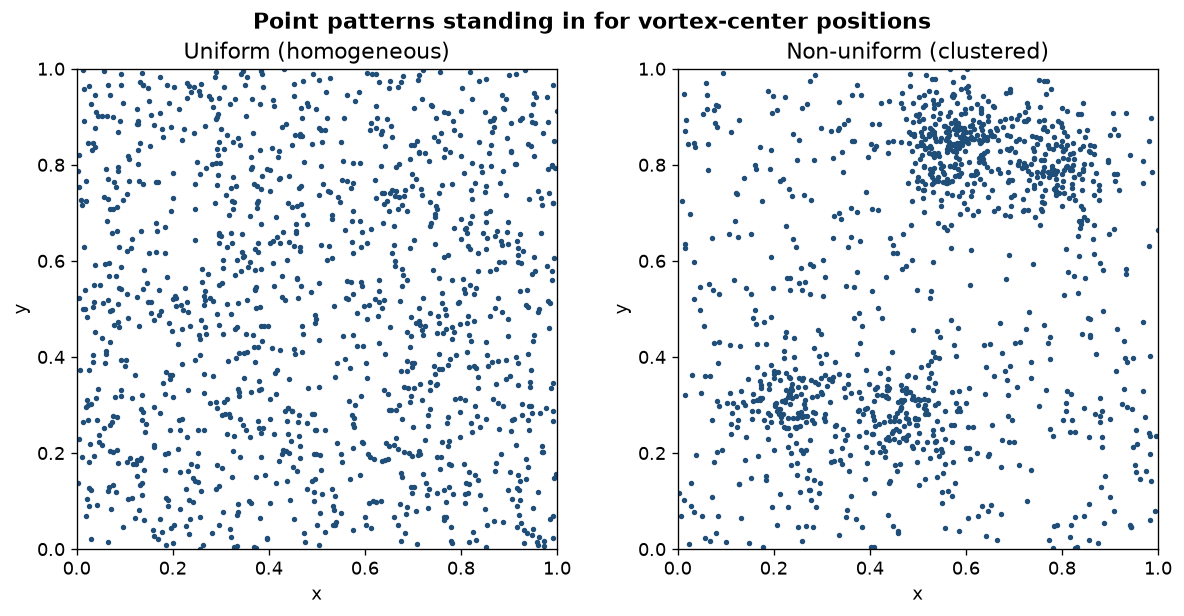

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
for a, p, t in zip(ax, (pts_uni, pts_clu), ("Uniform (homogeneous)", "Non-uniform (clustered)")):
    a.scatter(p[:, 0], p[:, 1], s=5, color="#1f4e79")
    a.set(title=t, xlim=(0, L), ylim=(0, L), xlabel="x", ylabel="y")
    a.set_aspect("equal")
fig.suptitle("Point patterns standing in for vortex-center positions", fontweight="bold")
plt.show()


## 2. Voronoi tessellations

Each cell contains exactly one center; every point inside a cell is closer to that center
than to any other. Visually, the uniform pattern tiles into cells of **similar size**, while
the clustered pattern produces **tiny cells inside the blobs** and **large cells across the
voids** — the geometric signature of inhomogeneity.


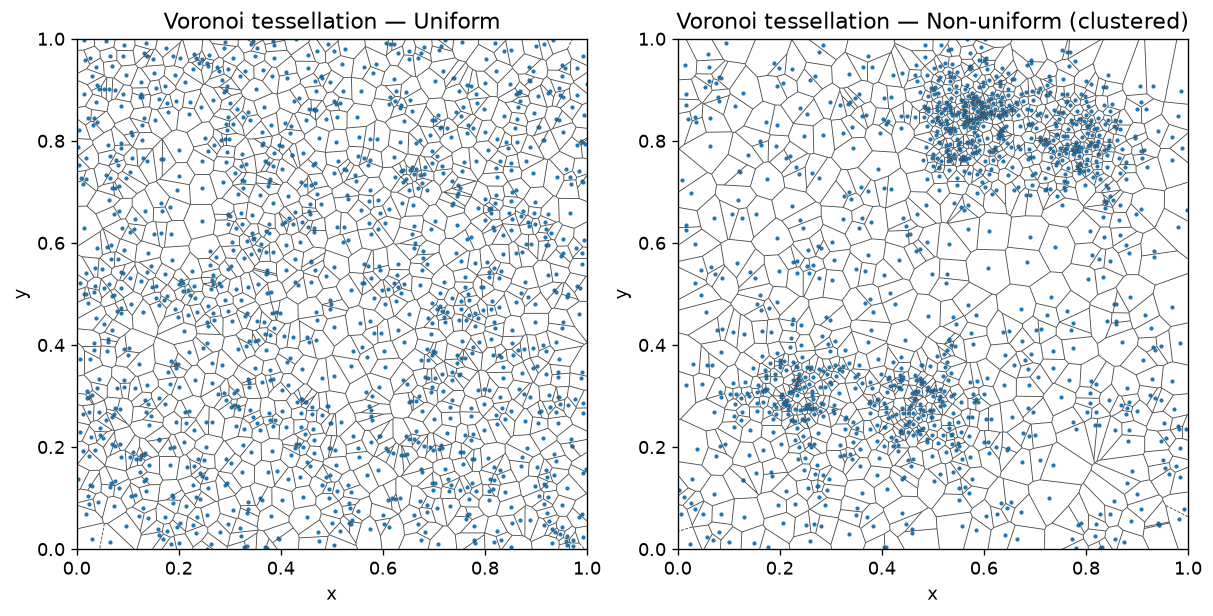

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
for a, p, t in zip(ax, (pts_uni, pts_clu), ("Uniform", "Non-uniform (clustered)")):
    vor = Voronoi(p)
    voronoi_plot_2d(vor, ax=a, show_points=True, show_vertices=False,
                    line_colors="#444", line_width=0.5, point_size=3)
    a.set(title=f"Voronoi tessellation — {t}", xlim=(0, L), ylim=(0, L),
          xlabel="x", ylabel="y")
    a.set_aspect("equal")
plt.show()


## 3. PDF of Voronoi cell area

Voronoi cells touching the domain boundary are unbounded (infinite area). We keep only
**finite, fully-interior** cells and compute each polygon's area with the shoelace formula.
Areas are normalised by the **mean cell area** $\langle A\rangle$ so the two patterns are
compared on the same axis (a homogeneous pattern then peaks near $A/\langle A\rangle = 1$).


In [5]:
def shoelace(poly):
    x, y = poly[:, 0], poly[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

def cell_areas(points, L, margin=0.04):
    '''Areas of finite Voronoi cells that lie fully inside [margin, L-margin].'''
    vor = Voronoi(points)
    lo, hi = margin, L - margin
    areas = []
    for ridx in vor.point_region:
        region = vor.regions[ridx]
        if len(region) == 0 or -1 in region:        # unbounded cell
            continue
        verts = vor.vertices[region]
        if (verts[:, 0] < lo).any() or (verts[:, 0] > hi).any() or \
           (verts[:, 1] < lo).any() or (verts[:, 1] > hi).any():
            continue                                  # touches/exceeds border
        areas.append(shoelace(verts))
    return np.asarray(areas)

A_uni = cell_areas(pts_uni, L)
A_clu = cell_areas(pts_clu, L)
A_uni_n = A_uni / A_uni.mean()       # normalise by <A>
A_clu_n = A_clu / A_clu.mean()
print(f"uniform   : {A_uni.size} cells,  std(A/<A>) = {A_uni_n.std():.3f}")
print(f"clustered : {A_clu.size} cells,  std(A/<A>) = {A_clu_n.std():.3f}")


uniform   : 948 cells,  std(A/<A>) = 0.537
clustered : 1053 cells,  std(A/<A>) = 1.181


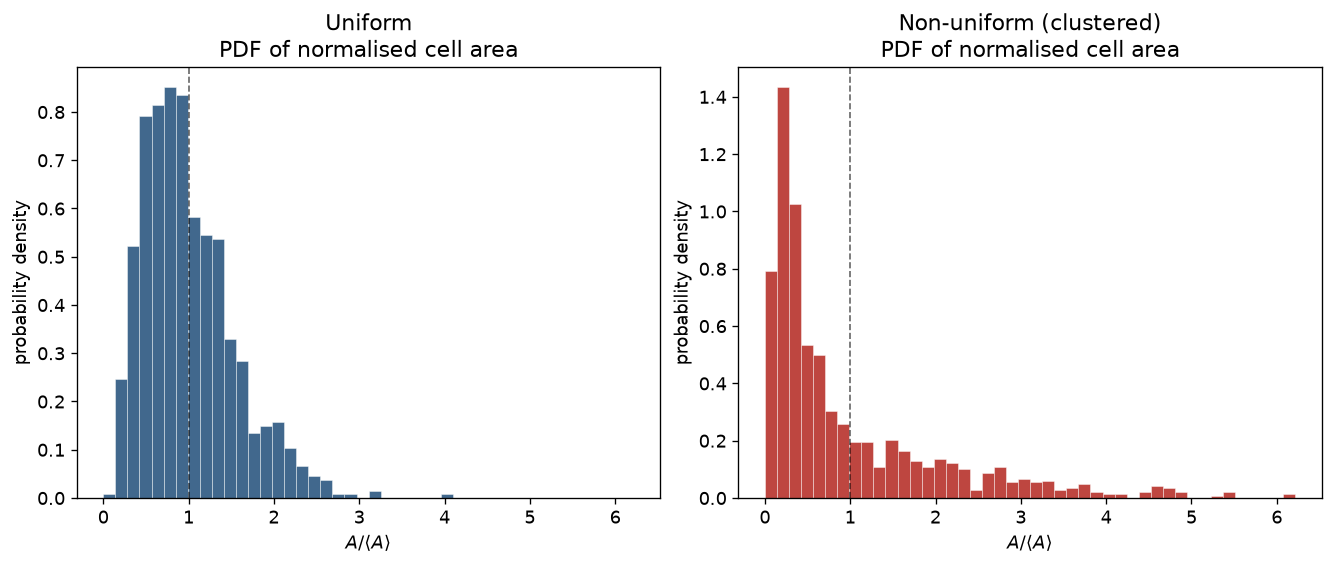

In [6]:
bins = np.linspace(0, max(A_uni_n.max(), np.quantile(A_clu_n, 0.995)), 45)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
for a, A, t, c in zip(ax, (A_uni_n, A_clu_n),
                      ("Uniform", "Non-uniform (clustered)"), ("#1f4e79", "#b3261e")):
    a.hist(A, bins=bins, density=True, color=c, alpha=0.85, edgecolor="white", linewidth=0.3)
    a.axvline(1.0, ls="--", color="k", lw=1, alpha=0.6)
    a.set(title=f"{t}\nPDF of normalised cell area", xlabel=r"$A/\langle A\rangle$",
          ylabel="probability density")
plt.show()


## 4. Comparison

Overlaying the two PDFs makes the contrast direct. The **uniform** pattern gives a
**narrow, single-peaked** distribution centred near $A/\langle A\rangle \approx 1$ (close to
the Poisson–Voronoi reference). The **clustered** pattern is **broad and right-skewed**: a
spike of small cells (dense clusters) plus a long tail of large cells (voids). The widening
spread — quantified below by the standard deviation and the **interquartile range (IQR)**,
exactly the diagnostic used in the paper's inset of Fig. S6(c) — is the Voronoi fingerprint of
the homogeneous → inhomogeneous (clustered) transition.


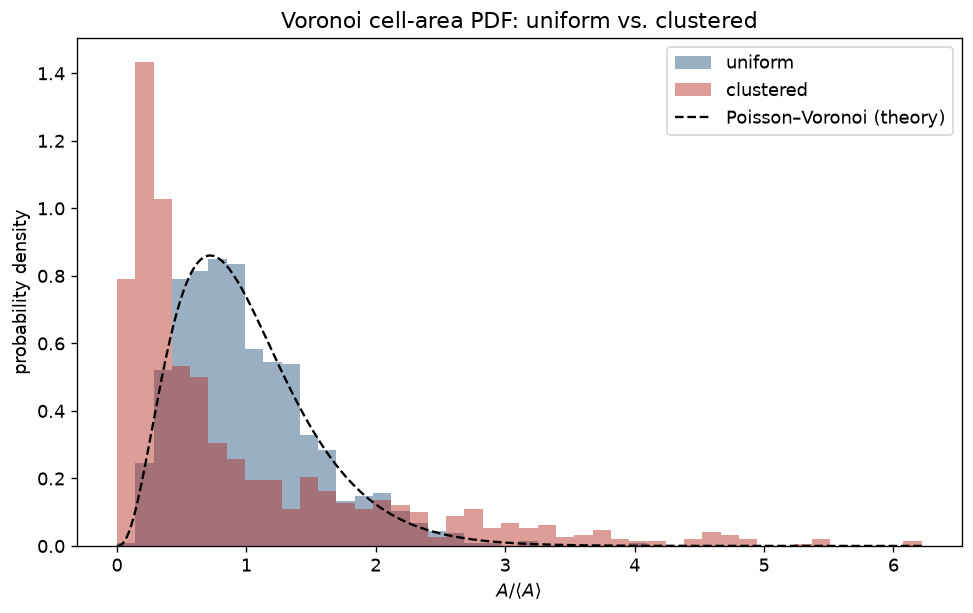

                 std     IQR    skew
uniform        0.537   0.689   1.082
clustered      1.181   1.158   2.221


In [7]:
from scipy.stats import gamma

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax.hist(A_uni_n, bins=bins, density=True, histtype="stepfilled", alpha=0.45,
        color="#1f4e79", label="uniform")
ax.hist(A_clu_n, bins=bins, density=True, histtype="stepfilled", alpha=0.45,
        color="#b3261e", label="clustered")

# Poisson-Voronoi reference: area/<A> ~ Gamma(shape~3.57) (Ferenc & Neda 2007)
x = np.linspace(0, bins.max(), 400)
ax.plot(x, gamma.pdf(x, a=3.57, scale=1/3.57), "k--", lw=1.4,
        label="Poisson–Voronoi (theory)")

ax.set(xlabel=r"$A/\langle A\rangle$", ylabel="probability density",
       title="Voronoi cell-area PDF: uniform vs. clustered")
ax.legend()
plt.show()

def iqr(a): return np.subtract(*np.percentile(a, [75, 25]))
print(f"{'':12s}{'std':>8s}{'IQR':>8s}{'skew':>8s}")
for name, A in (("uniform", A_uni_n), ("clustered", A_clu_n)):
    from scipy.stats import skew
    print(f"{name:12s}{A.std():8.3f}{iqr(A):8.3f}{skew(A):8.3f}")


**Takeaway.** A uniform set of vortex centers tiles into Voronoi cells of nearly equal area
(narrow PDF ≈ the Poisson–Voronoi gamma law). Clustering breaks that homogeneity: cell areas
spread over orders of magnitude, the PDF broadens and grows a heavy tail, and its **std / IQR
rise** — the same signature the paper reports as activity drops below $\alpha_c=-5$
(Fig. S6). This is the synthetic, ground-truth version of the analysis; the next step is to
feed in *real* vortex-center coordinates extracted from the simulated vorticity field
(Okubo–Weiss thresholding, Sec. S2) and repeat the tessellation.
